# Lab 2 Solutions: Pandas for Cat vs Dog Faces

These are worked solutions for the Pandas lab. The code below fills in each scaffolded task from the student notebook.

Set `STUDENT_ID` in the first code cell. Each notebook uses it as the random seed for sampling, split suggestions, and visualization so every student gets a reproducible variant.


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from lab_utils.visualization import (
    plot_class_balance,
    plot_error_rate_by_group,
    plot_numeric_distribution,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data" / "cats_dogs_faces_small").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "cats_dogs_faces_small"
METADATA_PATH = DATA_ROOT / "metadata.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABELS = ("cat", "dog")
SPLITS = ("train", "val", "test")
STUDENT_ID = 10422021  # Replace with your own student ID.
SEED = int(STUDENT_ID)
np.random.seed(SEED)
NUMPY_PRED_PATH = ARTIFACT_DIR / f"lab1_numpy_predictions_{STUDENT_ID}.csv"

def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            label_dir = data_root / split / label
            for path in sorted(label_dir.glob("*.jpg")) + sorted(label_dir.glob("*.png")):
                with Image.open(path) as image:
                    image = image.convert("RGB")
                    width, height = image.size
                    arr = np.asarray(image, dtype=np.float32) / 255.0
                rows.append(
                    {
                        "filepath": str(path.relative_to(data_root)),
                        "label": label,
                        "split": split,
                        "width": width,
                        "height": height,
                        "mean_intensity": float(arr.mean()),
                    }
                )
    return pd.DataFrame(rows)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the prepared subset at data/cats_dogs_faces_small/."
    )

if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
else:
    df = build_metadata_from_folders(DATA_ROOT)
    print("metadata.csv was not found, so a dataframe was built directly from the folders.")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   filepath        600 non-null    str    
 1   label           600 non-null    str    
 2   split           600 non-null    str    
 3   width           600 non-null    int64  
 4   height          600 non-null    int64  
 5   mean_intensity  600 non-null    float64
 6   source_path     600 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 32.9 KB


### Visual Helper: Quick Dataset Overview

These plots give students a fast visual summary of class balance and brightness before they start writing Pandas analysis code.


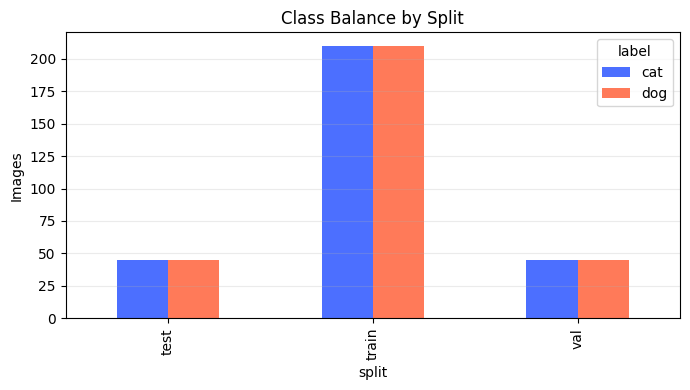

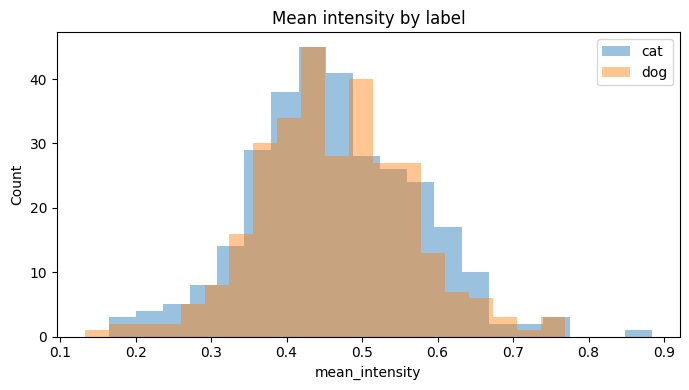

In [20]:
plot_class_balance(df)

if "mean_intensity" in df.columns:
    plot_numeric_distribution(
        df,
        column="mean_intensity",
        group_col="label",
        title="Mean intensity by label",
    )


## Question 1: What does the dataset table tell us?

Use Pandas operations to answer:

- How many rows are in the dataframe?
- What are the column names?
- How many cats and dogs do we have?
- How are examples distributed across splits?


In [21]:
num_rows = len(df)
column_names = df.columns.tolist()
class_counts = df["label"].value_counts().sort_index()
split_counts = df["split"].value_counts().sort_index()

print("Rows:", num_rows)
print("Columns:", column_names)
print("Class counts:")
print(class_counts)
print("Split counts:")
print(split_counts)

assert num_rows == len(df), "The row count should match the dataframe length."
assert "label" in column_names and "filepath" in column_names, "Important metadata columns are missing."


Rows: 600
Columns: ['filepath', 'label', 'split', 'width', 'height', 'mean_intensity', 'source_path']
Class counts:
label
cat    300
dog    300
Name: count, dtype: int64
Split counts:
split
test      90
train    420
val       90
Name: count, dtype: int64


## Question 2: Is the metadata clean?

Check for:

- missing values
- duplicated file paths
- unexpected labels
- invalid image sizes


In [22]:
def audit_metadata(frame: pd.DataFrame) -> dict:
    return {
        "missing_values": frame.isna().sum().to_dict(),
        "duplicate_filepaths": int(frame["filepath"].duplicated().sum()),
        "bad_labels": frame.loc[~frame["label"].isin(LABELS), "label"].unique().tolist(),
        "non_positive_sizes": int(((frame["width"] <= 0) | (frame["height"] <= 0)).sum()),
    }

audit_report = audit_metadata(df)
audit_report


{'missing_values': {'filepath': 0,
  'label': 0,
  'split': 0,
  'width': 0,
  'height': 0,
  'mean_intensity': 0,
  'source_path': 0},
 'duplicate_filepaths': 0,
 'bad_labels': [],
 'non_positive_sizes': 0}

## Question 3: Create useful columns for analysis

Add these columns:

- `pixel_count = width * height`
- `aspect_ratio = width / height`
- `brightness_band` using 4 bins from darkest to brightest
- `size_bucket` using labels such as `small`, `medium`, and `large`

Use `pd.qcut` for the brightness bands.


In [23]:
analysis_df = df.copy()
analysis_df["pixel_count"] = analysis_df["width"] * analysis_df["height"]
analysis_df["aspect_ratio"] = analysis_df["width"] / analysis_df["height"]
analysis_df["brightness_band"] = pd.qcut(
    analysis_df["mean_intensity"],
    q=4,
    labels=["darkest", "dim", "bright", "brightest"],
    duplicates="drop",
)

base_pixels = 64 * 64
analysis_df["size_bucket"] = np.select(
    [
        analysis_df["pixel_count"] < base_pixels,
        analysis_df["pixel_count"] == base_pixels,
        analysis_df["pixel_count"] > base_pixels,
    ],
    ["small", "medium", "large"],
    default="unknown",
)

analysis_df.head()


,filepath,label,split,width,height,mean_intensity,source_path,pixel_count,aspect_ratio,brightness_band,size_bucket
0,train/cat/cat_0000.jpg,cat,train,64,64,0.584909,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,brightest,medium
1,train/cat/cat_0001.jpg,cat,train,64,64,0.403741,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,dim,medium
2,train/cat/cat_0002.jpg,cat,train,64,64,0.450109,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,dim,medium
3,train/cat/cat_0003.jpg,cat,train,64,64,0.452337,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,dim,medium
4,train/cat/cat_0004.jpg,cat,train,64,64,0.427763,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,dim,medium


## Question 4: Can you create a stratified split suggestion?

Pretend the dataset came without a split column. Create a new column called
`recommended_split` with a **70 / 15 / 15** split, while keeping cats and dogs balanced.

Hint:

1. Shuffle the rows once with a fixed random seed
2. Count the rank of each example inside its label group
3. Convert ranks into split labels


In [24]:
shuffled_df = analysis_df.sample(frac=1.0, random_state=SEED).copy()
label_rank = shuffled_df.groupby("label").cumcount()
label_size = shuffled_df.groupby("label")["filepath"].transform("size")
train_cutoff = (0.70 * label_size).astype(int)
val_cutoff = (0.85 * label_size).astype(int)

shuffled_df["recommended_split"] = np.where(
    label_rank < train_cutoff,
    "train",
    np.where(label_rank < val_cutoff, "val", "test"),
)

split_balance = shuffled_df.groupby(["recommended_split", "label"]).size().unstack(fill_value=0)
split_balance


label,cat,dog
recommended_split,,
test,45,45
train,210,210
val,45,45


## Question 5: Merge the NumPy baseline predictions

Load the CSV saved in Lab 1 and merge it with the metadata dataframe using `filepath`.
Then create a boolean column called `correct_numpy` if it is missing.


In [25]:
if not NUMPY_PRED_PATH.exists():
    raise FileNotFoundError(
        f"Run Lab 1 first with STUDENT_ID={STUDENT_ID} so {NUMPY_PRED_PATH.name} is available."
    )

numpy_pred_df = pd.read_csv(NUMPY_PRED_PATH)
merged_df = analysis_df.merge(numpy_pred_df, on=["filepath", "label"], how="inner")

if "correct_numpy" not in merged_df.columns:
    merged_df["correct_numpy"] = merged_df["label"] == merged_df["pred_numpy"]

merged_df.head()


,filepath,label,split,width,height,mean_intensity,source_path,pixel_count,aspect_ratio,brightness_band,size_bucket,pred_numpy,correct_numpy
0,test/cat/cat_0000.jpg,cat,test,64,64,0.538470,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,brightest,medium,dog,False
1,test/cat/cat_0001.jpg,cat,test,64,64,0.476347,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,bright,medium,dog,False
2,test/cat/cat_0003.jpg,cat,test,64,64,0.529344,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,bright,medium,dog,False
3,test/cat/cat_0004.jpg,cat,test,64,64,0.390794,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,darkest,medium,cat,True
4,test/cat/cat_0005.jpg,cat,test,64,64,0.350820,/Users/fuisloy/lab/data/raw/animal-faces/afhq/...,4096,1.0,darkest,medium,cat,True


## Question 6: Where is the baseline doing well or poorly?

Build summary tables for:

- overall NumPy accuracy
- NumPy accuracy by split
- NumPy accuracy by class
- count of correct vs incorrect predictions


Overall accuracy: 0.43333333333333335
Accuracy by split:
split
test    0.433333
Name: correct_numpy, dtype: float64
Accuracy by class:
label
cat    0.466667
dog    0.400000
Name: correct_numpy, dtype: float64
Correct vs incorrect:
correct_numpy
False    34
True     26
Name: count, dtype: int64


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'NumPy error rate by split'}, xlabel='split', ylabel='Error rate'>)

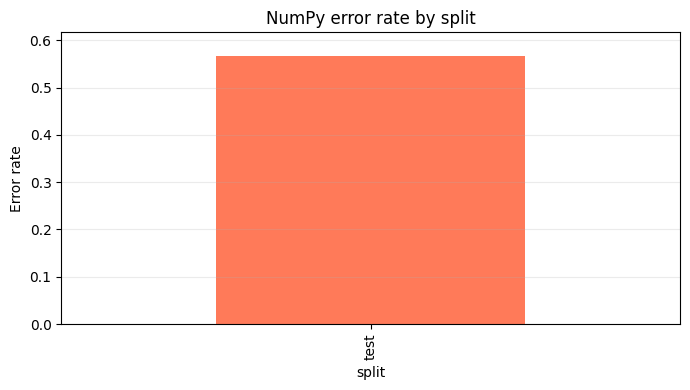

In [26]:
if merged_df is None:
    raise ValueError("Complete Question 5 before continuing.")

overall_accuracy = float(merged_df["correct_numpy"].mean())
accuracy_by_split = merged_df.groupby("split")["correct_numpy"].mean()
accuracy_by_class = merged_df.groupby("label")["correct_numpy"].mean()
correctness_counts = merged_df["correct_numpy"].value_counts().sort_index()

print("Overall accuracy:", overall_accuracy)
print("Accuracy by split:")
print(accuracy_by_split)
print("Accuracy by class:")
print(accuracy_by_class)
print("Correct vs incorrect:")
print(correctness_counts)

plot_error_rate_by_group(
    merged_df,
    group_col="split",
    correct_col="correct_numpy",
    title="NumPy error rate by split",
)


## Question 7: Analyze failure patterns

Focus only on the mistakes and answer:

- Are errors more common in darker images or brighter images?
- Are errors more common in smaller images?
- Which class is harder for the NumPy baseline?

Save your final merged dataframe to:

`artifacts/lab2_error_analysis.csv`


Errors by brightness band:
brightness_band
darkest      11
dim           6
bright        6
brightest    11
dtype: int64
Errors by label and size bucket:
size_bucket  medium
label              
cat              16
dog              18
Saved merged analysis dataframe to: /Users/fuisloy/lab/artifacts/lab2_error_analysis.csv


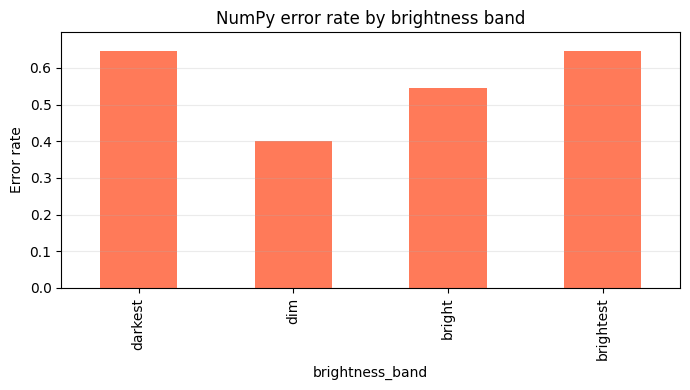

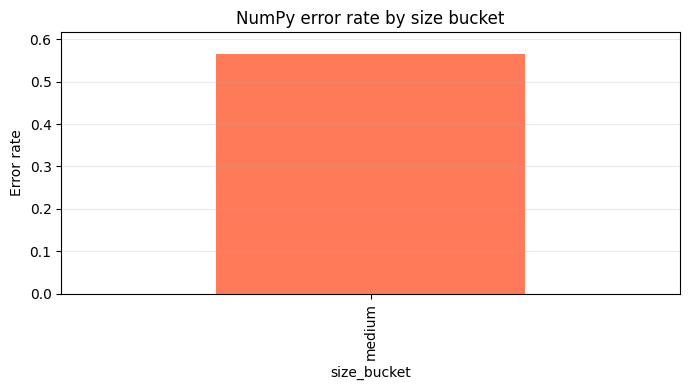

In [27]:
if merged_df is None:
    raise ValueError("Complete Question 5 before continuing.")

errors_only = merged_df[~merged_df["correct_numpy"]].copy()
errors_by_brightness = errors_only.groupby("brightness_band", observed=False).size()
errors_by_label_size = errors_only.groupby(["label", "size_bucket"], observed=False).size().unstack(fill_value=0)

print("Errors by brightness band:")
print(errors_by_brightness)
print("Errors by label and size bucket:")
print(errors_by_label_size)

output_path = ARTIFACT_DIR / "lab2_error_analysis.csv"
merged_df.to_csv(output_path, index=False)
print(f"Saved merged analysis dataframe to: {output_path}")

if "brightness_band" in merged_df.columns:
    plot_error_rate_by_group(
        merged_df,
        group_col="brightness_band",
        correct_col="correct_numpy",
        title="NumPy error rate by brightness band",
    )

if "size_bucket" in merged_df.columns:
    plot_error_rate_by_group(
        merged_df,
        group_col="size_bucket",
        correct_col="correct_numpy",
        title="NumPy error rate by size bucket",
    )


## Reflection

Write short answers to these questions:

1. Is the dataset balanced across classes and splits?
2. What kind of images seem hardest for the NumPy baseline?
3. What is one data or modeling improvement you would try before Lab 3?

**Optional extension**

Compare the average `mean_intensity` of correct vs incorrect predictions and decide whether brightness looks truly important.
